In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
sns.set_style('whitegrid')

## 1. Initial Data Audit & Structural Integrity Check

In [3]:
df = pd.read_csv('../data/titanic.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.head()

Shape: 887 rows, 8 columns

Missing values:
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64

Duplicates: 70


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


**Key Findings from the Initial Check:**

* **Dataset Size:** The dataset has 887 rows and 8 columns. This means we have data for 887 passengers.
* **Missing Values:** There are **0 missing values** in the entire table. The data is already clean, so we do not need to fill in any empty cells.
* **Duplicate Rows:** There are **70 duplicate rows**. We need to look closely at these rows in the next step to see if they are errors or real data.

## 2. Deep Dive into Duplicate Rows

In our initial check, we found 70 duplicate rows. Now, we will look closer at these rows. First, we will display the duplicate rows side-by-side. Then, we will aggregate (group) them to see which passenger profiles repeat the most. This helps us decide if we should delete or keep this data.

In [4]:
print("--- Sample of Duplicate Rows (Side-by-Side) ---")
dup_groups = (
    df[df.duplicated(keep=False)]
    .assign(row_index=lambda x: x.index)
    .sort_values(list(df.columns))
)
display(dup_groups.head(10))

print("\n--- Summary of Duplicate Profiles and Counts ---")
dup_summary = (
    df[df.duplicated(keep=False)]
    .groupby(list(df.columns), dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(dup_summary.head(10))

--- Sample of Duplicate Rows (Side-by-Side) ---


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived,row_index
466,0,0.75,3,19.2583,0,0,1,1,466
641,0,0.75,3,19.2583,0,0,1,1,641
240,0,18.00,1,15.5000,0,0,1,1,240
609,0,18.00,1,15.5000,0,0,1,1,609
262,0,21.00,0,7.7500,0,0,1,0,262
498,0,21.00,0,7.7500,0,0,1,0,498
140,0,22.00,0,7.7500,0,0,1,1,140
287,0,22.00,0,7.7500,0,0,1,1,287
366,0,22.00,0,7.7500,0,0,1,1,366
570,0,22.00,0,7.7500,0,0,1,1,570



--- Summary of Duplicate Profiles and Counts ---


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived,count
22,1,23.0,0,7.8958,0,0,1,0,5
3,0,22.0,0,7.7500,0,0,1,1,4
21,1,22.0,0,8.0500,0,0,1,0,4
15,1,20.0,0,8.0500,0,0,1,0,3
9,1,17.0,0,8.6625,0,0,1,0,3
20,1,22.0,0,7.8958,0,0,1,0,3
40,1,32.0,0,56.4958,0,0,1,1,3
42,1,34.0,0,8.0500,0,0,1,0,3
11,1,19.0,0,7.8958,0,0,1,0,3
23,1,23.0,0,13.0000,0,1,0,0,3


**Conclusion & Data Strategy for Duplicates:**

* **Plausible Data Profiles:** The identical rows show passengers who share the exact same traits (such as gender, age, class, and fare). These combinations are completely possible in real life (for example, multiple young men traveling alone in third class).
* **Lack of Features:** Because the dataset does not include unique identifiers like passenger names or ticket numbers, we cannot be certain if these rows are accidental system duplicates or distinct historical individuals.
* **Our Decision:** If we had more columns with additional information, we could check and verify these rows properly. However, with the current features, deleting these rows might remove valid data and change the true survival rates. Therefore, **we will keep all identical rows** for our machine learning model to avoid losing real information.

## 3. Data Types and Descriptive Statistics

In [5]:
print("--- Dataset Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
df.describe()

zero_fare_count = (df['fare'] == 0).sum()
print(f"\nNumber of passengers with a zero fare: {zero_fare_count}")

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB

--- Descriptive Statistics ---

Number of passengers with a zero fare: 15


**Key Findings:**

* **Data Types:** All columns are numeric (`int64` or `float64`). Categorical columns (`sex`, `1st_class`, `2nd_class`, `3rd_class`) are already encoded as binary (0 or 1).
* **Age:** The average passenger age is 29.5 years, ranging from 0.42 to 80 years.
* **Fare Distributions:** The average fare is £32.3, with a maximum of £512.3. This shows a strong right skew with high outliers.
* **Zero Fares:** There are exactly 15 rows where the fare is £0.0. These likely represent ship crew, logistics staff, or complimentary tickets, so they are kept as valid records.
* **Target Variable:** The baseline survival rate is 38.6%, meaning 61.4% of the passengers in this dataset died.

## 4. Target Variable Balance (Survival Distribution)

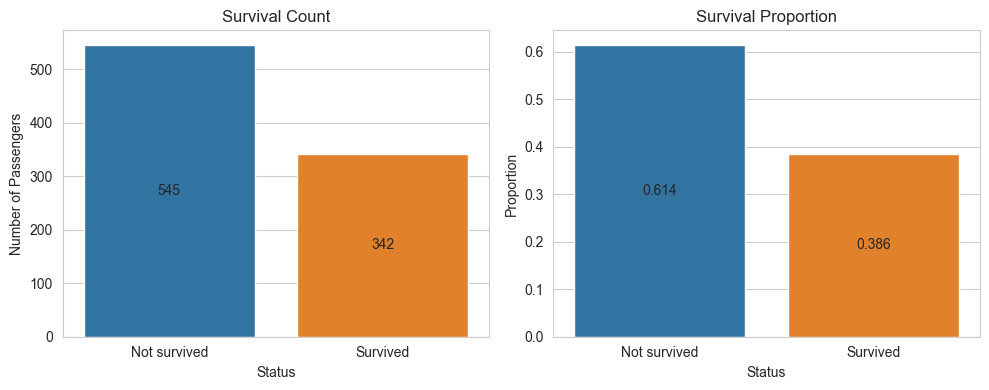

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left chart: Survival Count
sns.countplot(x='survived', hue='survived', data=df, ax=axes[0], legend=False)
axes[0].set_title('Survival Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not survived', 'Survived'])
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Passengers')
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='center')

# Right chart: Survival Proportion
df_prop = df['survived'].value_counts(normalize=True).reset_index(name='proportion')
sns.barplot(x='survived', y='proportion', hue='survived', data=df_prop, ax=axes[1], legend=False)
axes[1].set_title('Survival Proportion')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not survived', 'Survived'])
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Proportion')
for container in axes[1].containers:
    axes[1].bar_label(container, label_type='center', fmt='%.3f')

plt.tight_layout()
plt.show()

**Key Findings:**

* **Class Imbalance:** The target variable `survived` shows a clear split but is imbalanced.
* **Survival Count:** Approximately 545 passengers did not survive, while 342 passengers survived.
* **Proportions:** 61.4% of the passengers died and 38.6% survived. This establishes our baseline survival rate.

## 5. Numerical Feature Distributions (Age, Fare, and Family Size)

### 5.1 Age Distribution

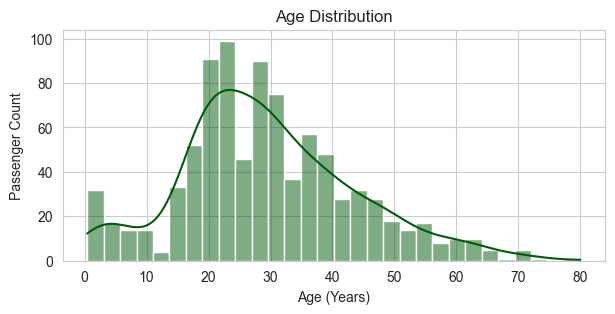

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(7, 3))

sns.histplot(data=df, x='age', bins=30, kde=True, ax=axes, color="#025a0c")

axes.set_title('Age Distribution')
axes.set_xlabel('Age (Years)')
axes.set_ylabel('Passenger Count')

plt.show()

**Key Findings:**

* **Age:** Passenger ages follow a relatively normal distribution with a peak between 20 and 30 years old. The dataset includes a notable count of young children (infants).

### 5.2 Fare Distribution

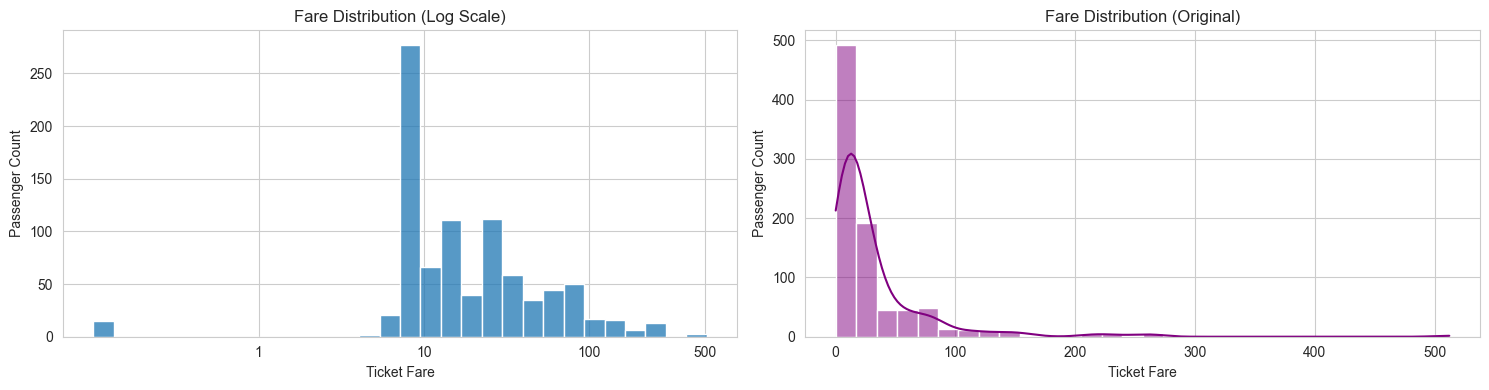

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. First plot: Log scale
fare_log = np.log10(df['fare'] + 0.1)
sns.histplot(x=fare_log, bins=30, kde=False, ax=axes[0])

axes[0].set_xticks([0, 1, 2, 2.7]) 
axes[0].set_xticklabels(['1', '10', '100', '500'])
axes[0].set_title('Fare Distribution (Log Scale)')
axes[0].set_xlabel('Ticket Fare')
axes[0].set_ylabel('Passenger Count')

# 2. Second plot: Original scale
sns.histplot(df['fare'], kde=True, color='purple', bins=30, ax=axes[1]) 

axes[1].set_title('Fare Distribution (Original)')
axes[1].set_xlabel('Ticket Fare')
axes[1].set_ylabel('Passenger Count')

plt.tight_layout()
plt.show()

In [9]:
fare_stats = df['fare'].describe().to_frame()
print("Fare Statistics:")
display(fare_stats)

df['fare'].describe()[['min', '50%', 'max']]

Fare Statistics:


,fare
count,887.00000
mean,32.30542
std,49.78204
min,0.00000
25%,7.92500
50%,14.45420
75%,31.13750
max,512.32920


min      0.0000
50%     14.4542
max    512.3292
Name: fare, dtype: float64

**Key Findings:**

* **The Range:** Passenger fares ranged from 0.00 to 512.33, with a median price of 14.45. 
* **The Distribution:** The data is right-skewed. Most people paid a low fare, while only a small number of passengers paid very high prices.

### 5.3 Family Size Distribution

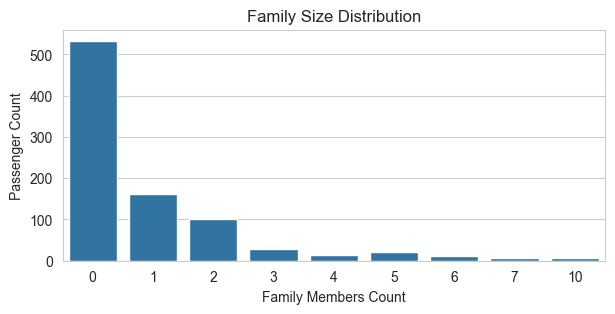

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(7, 3))

sns.countplot(data=df, x='family_size', ax=axes)
axes.set_title('Family Size Distribution')
axes.set_xlabel('Family Members Count')
axes.set_ylabel('Passenger Count')

plt.show()

**Key Findings:**

* **Family Size:** The vast majority of passengers traveled completely alone (Family Size = 0). As family size increases, the count of passengers drops drastically.

## 6. Survival Analysis by Categorical Features

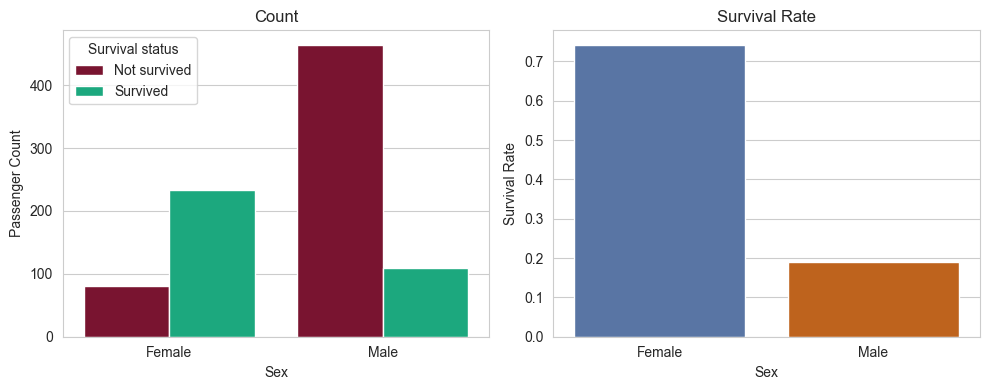

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='sex', hue='survived', data=df, ax=axes[0], hue_order=[0, 1], palette=["#8a0329", "#05bf87"])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].set_title('Count')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Passenger Count')
axes[0].legend(title='Survival status', labels=['Not survived', 'Survived'])

sns.barplot(x='sex', y='survived', hue='sex', data=df, ax=axes[1], errorbar=None, palette=['#4c72b0', "#d95f02"], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Female', 'Male'])
axes[1].set_title('Survival Rate')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

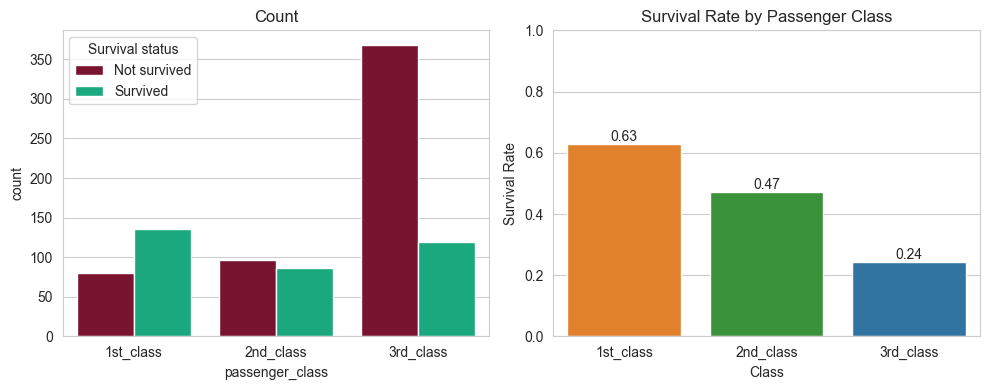

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

class_cols = ['1st_class', '2nd_class', '3rd_class']
df['passenger_class'] = df[class_cols].idxmax(axis=1)

sns.countplot(x='passenger_class', hue='survived', data=df, 
              order=['1st_class', '2nd_class', '3rd_class'],ax=axes[0], palette=["#8a0329", "#05bf87"])
axes[0].set_title('Count')
axes[0].legend(title='Survival status', labels=['Not survived', 'Survived'])

sns.barplot(
    x='passenger_class', 
    y='survived', 
    data=df, 
    errorbar=None, 
    hue='passenger_class', 
    legend=False,
    order=['1st_class', '2nd_class', '3rd_class'] 
)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Class')
plt.ylim(0, 1)

# Add labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

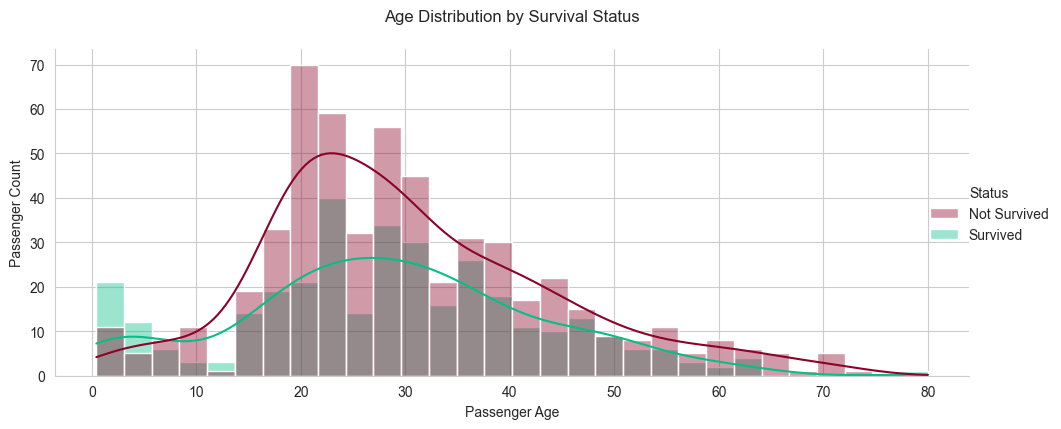

In [13]:
# g = sns.displot(
#     data=df, 
#     x='age', 
#     hue='survived', 
#     kind='hist',
#     bins=40, 
#     alpha=0.5,
#     height=4,
#     aspect=2.5
# )

# # g = sns.displot(
# #     data=df[df['age'].notna()], 
# #     x='age', 
# #     hue='survived', 
# #     kind='kde',
# #     fill=True,
# #     alpha=0.4,
# #     height=4, 
# #     aspect=2.5
# # ) 
g = sns.displot(
    data=df[df['age'].notna()], 
    x='age', 
    hue='survived', 
    kind='hist',
    kde=True,
    bins=30, 
    alpha=0.4,
    height=4, 
    aspect=2.5,
    palette=["#8a0329", "#05bf87"]
)

g.set_axis_labels("Passenger Age", "Passenger Count")
g.ax.set_title("Age Distribution by Survival Status", pad=20)
g.legend.set_title("Status")

labels_map = {'0': 'Not Survived', '1': 'Survived'}

for text in g.legend.texts:
    current_text = text.get_text()
    if current_text in labels_map:
        text.set_text(labels_map[current_text])

plt.show()

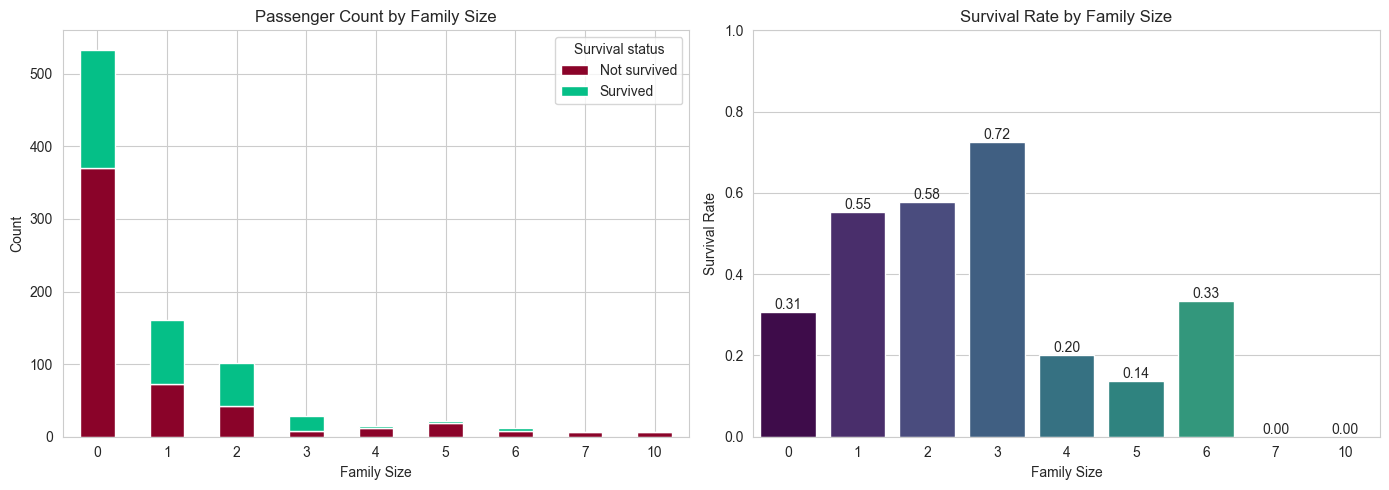

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = pd.crosstab(df['family_size'], df['survived'])
counts.plot(kind='bar', stacked=True, ax=axes[0], color=["#8a0329", "#05bf87"])
axes[0].set_title('Passenger Count by Family Size')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Count')
axes[0].legend(title='Survival status', labels=['Not survived', 'Survived'])
axes[0].tick_params(axis='x', rotation=0)

sns.barplot(
    x='family_size', 
    y='survived', 
    data=df, 
    errorbar=None, 
    hue='family_size', 
    palette='viridis', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_xlabel('Family Size')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

**Key Findings:**

* **Class Hierarchy:** The survival rate decreases progressively from 1st to 3rd class. 1st class passengers had the highest survival probability, followed by 2nd class, and then 3rd class.
* **Data Insight:** This visual confirms that socio-economic status was a primary determinant of survival on the Titanic, with a significant disparity in outcomes between the classes.

## 7. Correlation Heatmap

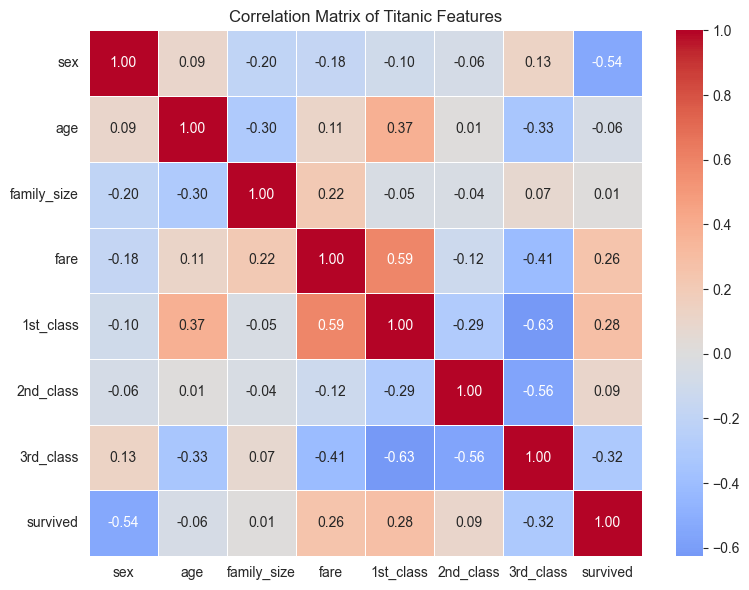

In [15]:
# corr = df.corr(numeric_only=True)
# corr = df.drop(columns='passenger_class').corr()
corr = df.drop(columns='passenger_class', errors='ignore').corr(numeric_only=True)

# Create the heatmap using the object-oriented approach
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            center=0, linewidths=0.5, ax=ax)

plt.title('Correlation Matrix of Titanic Features')
plt.tight_layout()
plt.show()

**Key Findings:**

* **Sex** has the strongest relationship with survival, so it is the most important feature in this matrix.
* Several features are related to survival, but no single numeric variable fully explains the outcome on its own.
* The matrix is useful for spotting relationships between variables before modeling.
* The strongest patterns should be considered together rather than in isolation.